<a href="https://colab.research.google.com/github/jiyasahni-maker/Ai-Ml-Assignments/blob/main/week4_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Loan prediction.csv to Loan prediction.csv


In [3]:
df = pd.read_csv("Loan prediction.csv")

In [4]:
# question 1
df.head(10)
print("Features:")

print(df.columns[:-1])

print("\nTarget Variable:")

print(df.columns[-1])
print(df.shape)
df.isnull().sum()
df.describe()

Features:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

Target Variable:
Loan_Status
(614, 13)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
# question 2
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)
le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]
scaler = StandardScaler()

X = scaler.fit_transform(X)

/tmp/ipykernel_1181/3532686489.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1181/3532686489.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

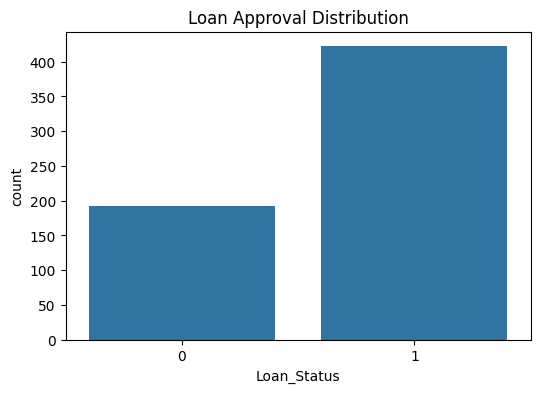

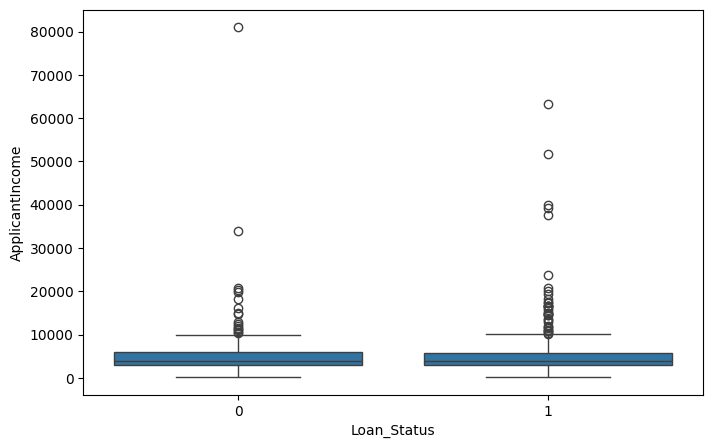

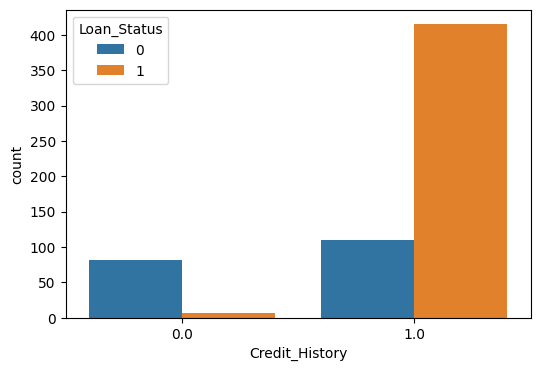

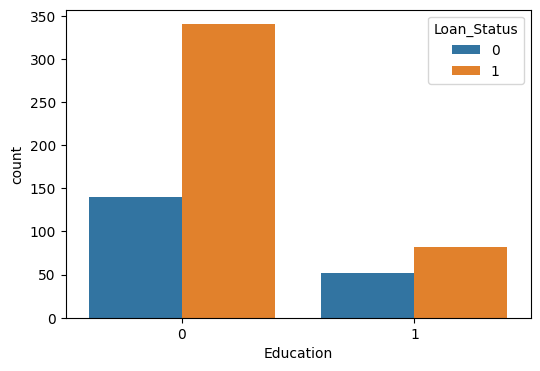

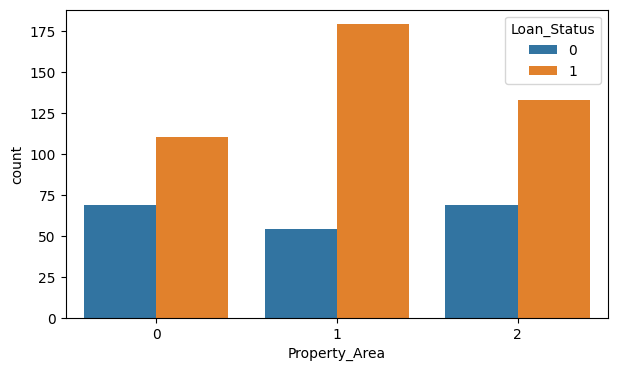

In [6]:
# question 3
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.show()
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.show()
plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.show()
plt.figure(figsize=(7,4))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.show()

In [7]:
# question 4
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)
def evaluate(y_test,pred):

    return [
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ]
results = pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy":[evaluate(y_test,pred_lr)[0],
                evaluate(y_test,pred_dt)[0],
                evaluate(y_test,pred_rf)[0]],
    "Precision":[evaluate(y_test,pred_lr)[1],
                 evaluate(y_test,pred_dt)[1],
                 evaluate(y_test,pred_rf)[1]],
    "Recall":[evaluate(y_test,pred_lr)[2],
              evaluate(y_test,pred_dt)[2],
              evaluate(y_test,pred_rf)[2]],
    "F1 Score":[evaluate(y_test,pred_lr)[3],
                evaluate(y_test,pred_dt)[3],
                evaluate(y_test,pred_rf)[3]]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108
1,Decision Tree,0.764228,0.825581,0.835294,0.830409
2,Random Forest,0.813008,0.822917,0.929412,0.872928


# **Question 5**
1. Identify the best-performing model.

The Logistic Regression model is the best-performing model. It achieved the highest Accuracy (86.18%), Precision (84.00%), Recall (98.82%), and F1 Score (90.81%) among all three models.

2. Justify your choice using evaluation metrics.

Logistic Regression outperformed the other models across all evaluation metrics:

Highest Accuracy (86.18%) indicates it correctly classified the largest number of loan applications.
Highest Precision (84.00%) means it made fewer incorrect loan approval predictions compared to the other models.
Highest Recall (98.82%) shows that it successfully identified almost all approved loan applications, minimizing false negatives.
Highest F1 Score (90.81%) demonstrates the best balance between precision and recall, making it the most reliable model for this classification problem.

Therefore, Logistic Regression is the most suitable model for predicting loan approval in this dataset.

3. Discuss the strengths and limitations of each model.
Logistic Regression

Strengths

Highest overall performance among all models.
Simple, fast, and computationally efficient.
Easy to interpret and explain.
Performs well on linearly separable data.

Limitations

Assumes a linear relationship between features and the target.
May not capture complex non-linear patterns present in the data.
Decision Tree

Strengths

Easy to understand and visualize.
Can capture non-linear relationships.
Requires minimal data preprocessing.

Limitations

Lowest accuracy (76.42%) among the three models.
More prone to overfitting.
Performance can vary significantly with small changes in the training data.
Random Forest

Strengths

More robust than a single Decision Tree.
Reduces overfitting by combining multiple trees.
Handles complex relationships and interactions between features effectively.

Limitations

More computationally expensive than Logistic Regression.
Less interpretable because it consists of many decision trees.
In this dataset, it performed better than the Decision Tree but did not outperform Logistic Regression.
Conclusion

Among the three models, Logistic Regression is the best choice for the Loan Approval Prediction task because it achieved the highest Accuracy (86.18%), Precision (84.00%), Recall (98.82%), and F1 Score (90.81%). Its excellent performance indicates that the dataset is well-suited for a linear classification model, making Logistic Regression both accurate and efficient for predicting loan approvals.

In [8]:
# question 6
models = {
    "Logistic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42)
}

skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

for name,model in models.items():

    scores = cross_val_score(model,X,y,cv=skf)

    print(name)

    print(scores)

    print("Mean:",scores.mean())

    print("Std:",scores.std())

    print()

Logistic Regression
[0.81300813 0.82113821 0.80487805 0.75609756 0.82786885]
Mean: 0.8045981607357058
Std: 0.025448821062939588

Decision Tree
[0.73170732 0.72357724 0.69105691 0.6504065  0.7295082 ]
Mean: 0.7052512328401972
Std: 0.031092089451490786

Random Forest
[0.78861789 0.81300813 0.79674797 0.7398374  0.78688525]
Mean: 0.7850193256030921
Std: 0.024408080880327237



In [9]:
# question 7
param_grid = {

    "n_estimators":[50,100,200],
    "max_depth":[3,5,10],
    "min_samples_split":[2,5,10]

}
grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring='accuracy'

)

grid.fit(X_train,y_train)
print(grid.best_params_)

print(grid.best_score_)
best_rf = grid.best_estimator_

pred = best_rf.predict(X_test)

print(accuracy_score(y_test,pred))

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
0.8004122861265719
0.8455284552845529


In [10]:
# question 8
depths=[2,5,15]

for d in depths:

    model=DecisionTreeClassifier(max_depth=d,random_state=42)

    model.fit(X_train,y_train)

    train_acc=model.score(X_train,y_train)

    test_acc=model.score(X_test,y_test)

    print(d,train_acc,test_acc)

2 0.8044806517311609 0.8536585365853658
5 0.824847250509165 0.8373983739837398
15 1.0 0.7642276422764228
